# Ostoskärrydatan tutkimus (03) - Laajennettu analyysi

## Tietovaraston lataus

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta
import warnings
from matplotlib.colors import LogNorm

warnings.filterwarnings('ignore')

# Asetetaan visuaalinen tyyli
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Tarkistetaan datakansiot
raw_data_path = Path('data/raw')
processed_data_path = Path('data/processed')

print(f"Raw data path: {raw_data_path}")
print(f"Processed data path: {processed_data_path}")
print(f"\nRaw files: {list(raw_data_path.glob('*')) if raw_data_path.exists() else 'Path does not exist'}")

Raw data path: data/raw
Processed data path: data/processed

Raw files: [PosixPath('data/raw/node_53936.csv'), PosixPath('data/raw/node_53795.csv'), PosixPath('data/raw/node_53000.csv'), PosixPath('data/raw/node_51968.csv'), PosixPath('data/raw/node_51992.csv'), PosixPath('data/raw/node_53924.csv'), PosixPath('data/raw/node_64458.csv'), PosixPath('data/raw/node_51866.csv'), PosixPath('data/raw/node_54016.csv'), PosixPath('data/raw/node_52535.csv'), PosixPath('data/raw/node_52008.csv'), PosixPath('data/raw/node_51751.csv'), PosixPath('data/raw/node_42787.csv'), PosixPath('data/raw/node_53888.csv'), PosixPath('data/raw/node_53130.csv'), PosixPath('data/raw/node_45300.csv'), PosixPath('data/raw/node_51719.csv'), PosixPath('data/raw/node_51976.csv'), PosixPath('data/raw/node_53027.csv'), PosixPath('data/raw/node_3240.csv'), PosixPath('data/raw/node_52003.csv'), PosixPath('data/raw/node_51850.csv'), PosixPath('data/raw/node_52023.csv'), PosixPath('data/raw/node_53768.csv'), PosixPath('data/

## Datan lataus

In [109]:
# Ladataan raakadata CSV-tiedostoista
raw_file = 'data/raw/node_3224.csv'  # Voit muuttaa tätä

try:
    df = pd.read_csv(raw_file)
    print(f"✓ Data ladattu onnistuneesti: {raw_file}")
    print(f"\n📊 Datan koko: {df.shape[0]:,} riviä, {df.shape[1]} saraketta")
    print(f"\n📋 Sarakkeet: {list(df.columns)}")
except FileNotFoundError:
    print(f"✗ Virhe: Tiedostoa {raw_file} ei löydy.")
    print("Varmista, että data on ladattu data/raw/ -kansioon.")

✓ Data ladattu onnistuneesti: data/raw/node_3224.csv

📊 Datan koko: 6,136,400 riviä, 6 saraketta

📋 Sarakkeet: ['node_id', 'timestamp', 'x', 'y', 'z', 'q']


## Datan perustietojen tarkastelu

In [110]:
# Ensimäinen tarkastelu
print("="*60)
print(" DATAN PERUSTIEDOT ")
print("="*60)
print(f"\n📊 Datan koko: {df.shape[0]:,} riviä, {df.shape[1]} saraketta")

print("\n📋 Sarakkeet ja tyypit:")
print(df.dtypes)

print("\n❓ PUUTTUVAT ARVOT:")
null_counts = df.isnull().sum()
null_percentages = (null_counts / len(df)) * 100
null_df = pd.DataFrame({'Missing': null_counts, 'Percentage': null_percentages})
print(null_df[null_df['Missing'] > 0].sort_values('Missing', ascending=False))

print("\n📈 PERUSTILASTOT:")
print(df.describe())

 DATAN PERUSTIEDOT 

📊 Datan koko: 6,136,400 riviä, 6 saraketta

📋 Sarakkeet ja tyypit:
node_id      int64
timestamp      str
x            int64
y            int64
z            int64
q            int64
dtype: object

❓ PUUTTUVAT ARVOT:
Empty DataFrame
Columns: [Missing, Percentage]
Index: []

📈 PERUSTILASTOT:
         node_id             x             y          z             q
count  6136400.0  6.136400e+06  6.136400e+06  6136400.0  6.136400e+06
mean      3224.0  7.454299e+02  2.559704e+03        0.0  6.265460e+01
std          0.0  1.994625e+03  6.763270e+02        0.0  2.745558e+01
min       3224.0 -3.281800e+04 -3.264500e+04        0.0  0.000000e+00
25%       3224.0 -4.000000e+00  2.475000e+03        0.0  4.800000e+01
50%       3224.0  1.000000e+02  2.556000e+03        0.0  5.700000e+01
75%       3224.0  1.900000e+02  2.636000e+03        0.0  6.800000e+01
max       3224.0  3.271100e+04  3.240300e+04        0.0  2.550000e+02


## Datan siivous

In [111]:
# Poistetaan rivit, joissa on puuttuvia arvoja kriittisissä sarakkeissa
critical_columns = ['node_id', 'timestamp', 'x', 'y', 'z']
available_columns = [col for col in critical_columns if col in df.columns]

df_initial = df.copy()
df_cleaned = df.copy()
rows_dropped = 0

if available_columns:
    rows_dropped = len(df) - len(df.dropna(subset=available_columns))
    df_cleaned = df.dropna(subset=available_columns)
    print(f"🗑️  Rivit poistettu puuttuvista arvoista: {rows_dropped:,} ({rows_dropped/len(df)*100:.2f}%)")
else:
    print("⚠️  Huom: Kriittisiä sarakkeita ei löydy, ei suoritettu puuttuvien arvojen poistoa.")

# Valinnainen: Poistetaan sarakkeet, joissa on enemmän kuin 50% puuttuvia arvoja
threshold = 0.5 * len(df_cleaned)
cols_to_drop = df_cleaned.columns[df_cleaned.isnull().sum() > threshold].tolist()
if cols_to_drop:
    df_cleaned = df_cleaned.drop(columns=cols_to_drop)
    print(f"🗑️  Sarakkeet poistettu: {cols_to_drop}")

print(f"\n✅ Siivottu data: {df_cleaned.shape[0]:,} riviä, {df_cleaned.shape[1]} saraketta")

🗑️  Rivit poistettu puuttuvista arvoista: 0 (0.00%)

✅ Siivottu data: 6,136,400 riviä, 6 saraketta


## 🧹 Edistynyt datan siivous

In [112]:
# Edistynyt datan siivous -asetukset
Q_THRESHOLD = 0.0                    # Q-arvojen minimitasvo (negatiiviset arvot poistetaan)
SHOP_HOURS = {
    'mon-sat': (8, 21),              # Ma-Su: 08:00-21:00
    'sunday': (10, 20)               # Su: 10:00-20:00
}
PROBLEMATIC_COORDS = [
    {'x': 100, 'y': 2500, 'radius': 400}, # Turvaportit ja latauspiste (Säde 4m)
    {'x': 900, 'y': 3600, 'radius': 600}  # Alakerran latauspiste / liukuportaat (Säde 6m)
]
CHECKOUT_ZONE = {
    'x_min': 0, 'x_max': 700,        # Kassa-alue ja sen takainen poistumistie (päivitetty)
    'y_min': 0, 'y_max': 5220        # Jatkuu koko matkan alas ulko-oville asti
}

# ANTEEKSIANTAVAT NOPEUSFILTTERIT (Tuotantotaso)
MAX_JUMP_SPEED = 5.0                # Max sallittu pistekohtainen hyppy (5 m/s). Suodattaa paikannusvirheet armollisesti.
MAX_AVG_SPEED = 2.0                 # Max sallittu koko reissun keskinopeus (m/s). Suodattaa juoksijat/laitteet.
MIN_SESSION_POINTS = 15             # Pienin sallittu datapisteiden määrä per reissu
MIN_SESSION_DIST = 15.0             # Pienin sallittu kuljettu matka metreinä per reissu (poistaa paikallaan seisovat kärryt)

START_COORDINATES = (0, 0)          # Aloituskoordinaatit (käyttäjän hallittava)
MAX_X = 10406                       # Kaupan maksimileveys (1 yksikkö = 1 cm)
MAX_Y = 5220                        # Kaupan maksimikorkeus
FLIP_Y = True                       # Käännetäänkö Y-akseli pohjapiirroksen mukaiseksi?
TIMEZONE = 'Europe/Helsinki'        # Lokaali aikavyöhyke

FILTER_SHOP_HOURS = True            # Kytketään kauppa-aikafiltteri päälle
FILTER_CHECKOUT = True              # Poistetaanko kassa-alueen jälkeinen alue datasta?

print("⚙️ Datan siivous -asetukset:")
print(f"  - Kiihtyvyys/Nopeusfiltterit: Max hyppy {MAX_JUMP_SPEED} m/s (yksittäiset pisteet poistetaan), Max keskinopeus {MAX_AVG_SPEED} m/s")
print(f"  - Reissun minimivaatimukset: Matka {MIN_SESSION_DIST} m, Datapisteitä {MIN_SESSION_POINTS}")
print(f"  - Kassa-alueen poisto: {'KÄYTÖSSÄ' if FILTER_CHECKOUT else 'EI'}")
print(f"  - Poistettavia lataus/ongelma-alueita: {len(PROBLEMATIC_COORDS)} kpl")
print(f"  - Y-akselin kääntö: {'KÄYTÖSSÄ' if FLIP_Y else 'EI'}")

⚙️ Datan siivous -asetukset:
  - Kiihtyvyys/Nopeusfiltterit: Max hyppy 5.0 m/s (yksittäiset pisteet poistetaan), Max keskinopeus 2.0 m/s
  - Reissun minimivaatimukset: Matka 15.0 m, Datapisteitä 15
  - Kassa-alueen poisto: KÄYTÖSSÄ
  - Poistettavia lataus/ongelma-alueita: 2 kpl
  - Y-akselin kääntö: KÄYTÖSSÄ


In [113]:
# Edistynyt datan siivous -funktio
def clean_data(df, config):
    df_clean = df.copy()
    stats = {
        'original_rows': len(df),
        'removed_q_negative': 0,
        'removed_shop_hours': 0,
        'removed_problematic_coords': 0,
        'removed_start_coords': 0,
        'removed_invalid_coords': 0,
        'removed_checkout': 0,
        'removed_jumps': 0,
        'removed_bad_sessions': 0,
        'final_rows': 0
    }
    
    # 0. POISTETAAN DUPLIKAATIT (Estää nollalla jaon nopeuksia laskiessa)
    before = len(df_clean)
    df_clean = df_clean.drop_duplicates(subset=['node_id', 'timestamp'])
    print(f"🗑️  Saman millisekunnin tuplamittaukset: {before - len(df_clean):,} riviä poistettu")

    # 1. Konvertoidaan aikaleimat Suomen aikaan
    df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'], utc=True).dt.tz_convert(config['TIMEZONE'])
    
    # 2. Poista koordinaatit, jotka eivät ole sallituissa rajoissa
    before = len(df_clean)
    invalid_coords = df_clean[
        (df_clean['x'] < 0) | (df_clean['x'] > config['MAX_X']) |
        (df_clean['y'] < 0) | (df_clean['y'] > config['MAX_Y'])
    ].index
    df_clean = df_clean.drop(invalid_coords)
    stats['removed_invalid_coords'] = before - len(df_clean)
    print(f"🗑️  Virheelliset koordinaatit: {stats['removed_invalid_coords']:,} riviä poistettu")

    # 3. Poista problematiset koordinaatit (Latausasemat)
    # HUOM: Tämä tehdään ENNEN Y-akselin kääntämistä.
    before = len(df_clean)
    mask = pd.Series(False, index=df_clean.index)
    for area in config['PROBLEMATIC_COORDS']:
        in_x = (df_clean['x'] >= area['x'] - area['radius']) & (df_clean['x'] <= area['x'] + area['radius'])
        in_y = (df_clean['y'] >= area['y'] - area['radius']) & (df_clean['y'] <= area['y'] + area['radius'])
        mask = mask | (in_x & in_y)
    
    df_clean = df_clean[~mask]
    stats['removed_problematic_coords'] = before - len(df_clean)
    print(f"🗑️  Latauspisteet ja ongelma-alueet: {stats['removed_problematic_coords']:,} riviä poistettu")

    # 4. Kassa-alueen suodatus (Poistaa hengaamisen kassan jälkeen)
    if config.get('FILTER_CHECKOUT', False):
        before = len(df_clean)
        cz = config['CHECKOUT_ZONE']
        in_checkout = (df_clean['x'] >= cz['x_min']) & (df_clean['x'] <= cz['x_max']) & \
                      (df_clean['y'] >= cz['y_min']) & (df_clean['y'] <= cz['y_max'])
        df_clean = df_clean[~in_checkout]
        stats['removed_checkout'] = before - len(df_clean)
        print(f"🗑️  Kassa-alueen data (checkout): {stats['removed_checkout']:,} riviä poistettu")

    # 5. Aloituskoordinaatit (0,0 pisteet)
    before = len(df_clean)
    start_rows = df_clean[
        (df_clean['x'] == config['START_COORDINATES'][0]) & 
        (df_clean['y'] == config['START_COORDINATES'][1])
    ].index
    df_clean = df_clean.drop(start_rows)
    stats['removed_start_coords'] = before - len(df_clean)
    print(f"🗑️  Aloituskoordinaatit (0,0): {stats['removed_start_coords']:,} riviä poistettu")

    # 6. Käännä Y-akseli ympäri (pohjapiirroksen mukaiseksi)
    if config.get('FLIP_Y', False):
        df_clean['y'] = config['MAX_Y'] - df_clean['y']
        print(f"🔄  Y-akseli käännetty visuaalisesti oikein (Max Y: {config['MAX_Y']})")

    # 7. Poista rivit, joissa q < kynnysarvo
    if 'q' in df_clean.columns:
        before = len(df_clean)
        df_clean = df_clean[df_clean['q'] >= config['Q_THRESHOLD']]
        stats['removed_q_negative'] = before - len(df_clean)
        print(f"🗑️  Q-arvojen filtri: {stats['removed_q_negative']:,} riviä poistettu (q < {config['Q_THRESHOLD']})")
    
    # 8. Kauppa-aikafiltteri
    if config['FILTER_SHOP_HOURS']:
        df_clean['hour'] = df_clean['timestamp'].dt.hour
        df_clean['weekday'] = df_clean['timestamp'].dt.day_name()
        
        before = len(df_clean)
        is_weekday = df_clean['weekday'].isin(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'])
        is_sunday = df_clean['weekday'] == 'Sunday'
        
        valid_weekday_hours = (df_clean['hour'] >= config['SHOP_HOURS']['mon-sat'][0]) & (df_clean['hour'] < config['SHOP_HOURS']['mon-sat'][1])
        valid_sunday_hours = (df_clean['hour'] >= config['SHOP_HOURS']['sunday'][0]) & (df_clean['hour'] < config['SHOP_HOURS']['sunday'][1])
        
        valid_rows = (is_weekday & valid_weekday_hours) | (is_sunday & valid_sunday_hours)
        df_clean = df_clean[valid_rows]
        
        stats['removed_shop_hours'] = before - len(df_clean)
        print(f"🗑️  Kauppa-aikafiltri: {stats['removed_shop_hours']:,} riviä poistettu")

    # 9. TUOTANTOTASON SESSIO- JA HYPPYFILTTERI (ANTEEKSIANTAVA)
    print("⏳ Suodatetaan epärealistiset reitit ja poistetaan yksittäiset GPS-harppaukset...")
    df_clean = df_clean.sort_values(['node_id', 'timestamp']).reset_index(drop=True)
    
    # Määritetään sessiot (yli 30 min tauko = uusi reissu)
    time_diff = df_clean.groupby('node_id')['timestamp'].diff().dt.total_seconds()
    df_clean['is_new_session'] = (time_diff > 1800).astype(int)
    df_clean['session_id'] = df_clean.groupby('node_id')['is_new_session'].cumsum()
    df_clean['full_session_id'] = df_clean['node_id'].astype(str) + "_" + df_clean['session_id'].astype(str)
    
    # Lasketaan pisteiden väliset nopeudet (m/s) ensimmäisen kerran
    df_clean['dt'] = df_clean.groupby('full_session_id')['timestamp'].diff().dt.total_seconds().fillna(0)
    df_clean['dx'] = df_clean.groupby('full_session_id')['x'].diff().fillna(0)
    df_clean['dy'] = df_clean.groupby('full_session_id')['y'].diff().fillna(0)
    df_clean['dist_m'] = np.sqrt(df_clean['dx']**2 + df_clean['dy']**2) * 0.01 # 1 yksikkö = 1 cm
    df_clean['speed_mps'] = np.where(df_clean['dt'] > 0, df_clean['dist_m'] / df_clean['dt'], 0)

    # --- ANTEEKSIANTO-LOGIIKKA: Poistetaan vain ne yksittäiset häiriöpisteet, EI koko sessiota ---
    before_jumps = len(df_clean)
    bad_jumps_mask = df_clean['speed_mps'] > config['MAX_JUMP_SPEED']
    df_clean = df_clean[~bad_jumps_mask].copy()
    stats['removed_jumps'] = before_jumps - len(df_clean)
    print(f"🗑️  Yksittäiset signaalihypyt (>{config['MAX_JUMP_SPEED']} m/s) poistettu: {stats['removed_jumps']:,} riviä")
    
    # UUDELLEENLASKENTA: Koska poistimme pisteitä, lasketaan reitit ja matkat uudelleen puhtaasta datasta
    df_clean = df_clean.sort_values(['node_id', 'timestamp']).reset_index(drop=True)
    df_clean['dt'] = df_clean.groupby('full_session_id')['timestamp'].diff().dt.total_seconds().fillna(0)
    df_clean['dx'] = df_clean.groupby('full_session_id')['x'].diff().fillna(0)
    df_clean['dy'] = df_clean.groupby('full_session_id')['y'].diff().fillna(0)
    df_clean['dist_m'] = np.sqrt(df_clean['dx']**2 + df_clean['dy']**2) * 0.01
    
    # --- SESSIOIDEN LAADUNVARMISTUS ---
    session_stats = df_clean.groupby('full_session_id').agg(
        total_time=('timestamp', lambda x: (x.max() - x.min()).total_seconds()),
        total_dist=('dist_m', 'sum'),
        point_count=('x', 'count')
    )
    session_stats['avg_speed'] = np.where(session_stats['total_time'] > 0, session_stats['total_dist'] / session_stats['total_time'], 0)
    
    # Hylätään sessiot, jotka ovat joko liian nopeita, liian lyhyitä tai paikallaan seisovia
    bad_sessions = session_stats[
        (session_stats['avg_speed'] > config['MAX_AVG_SPEED']) |
        (session_stats['point_count'] < config['MIN_SESSION_POINTS']) |
        (session_stats['total_dist'] < config['MIN_SESSION_DIST'])
    ].index
    
    before_sess = len(df_clean)
    df_clean = df_clean[~df_clean['full_session_id'].isin(bad_sessions)]
    stats['removed_bad_sessions'] = before_sess - len(df_clean)
    print(f"🗑️  Virheelliset tai olemattomat haamureitit poistettu: {stats['removed_bad_sessions']:,} riviä ({len(bad_sessions)} hylättyä reissua)")
    
    # Siivotaan koodin apumuuttujat, tallennetaan nopeus tulevaa Dwell-analyysiä varten
    df_clean['speed_mps'] = np.where(df_clean['dt'] > 0, df_clean['dist_m'] / df_clean['dt'], 0)
    df_clean = df_clean.drop(columns=['is_new_session', 'session_id', 'dx', 'dy'])

    print(f"\n✅ Siivous valmis!")
    print(f"   - Alkuperäinen: {stats['original_rows']:,} riviä")
    print(f"   - Lopputulos: {len(df_clean):,} riviä")
    print(f"   - Poistettu yhteensä: {stats['original_rows'] - len(df_clean):,} riviä")
    
    return df_clean, stats

In [114]:
# Sovelletaan siivousfunktio koko dataan
df_cleaned, cleaning_stats = clean_data(df_cleaned, {
    'Q_THRESHOLD': Q_THRESHOLD,
    'SHOP_HOURS': SHOP_HOURS,
    'PROBLEMATIC_COORDS': PROBLEMATIC_COORDS,
    'CHECKOUT_ZONE': CHECKOUT_ZONE,
    'START_COORDINATES': START_COORDINATES,
    'MAX_X': MAX_X,
    'MAX_Y': MAX_Y,
    'FLIP_Y': FLIP_Y,
    'TIMEZONE': TIMEZONE,
    'FILTER_SHOP_HOURS': FILTER_SHOP_HOURS,
    'FILTER_CHECKOUT': FILTER_CHECKOUT,
    'MAX_AVG_SPEED': MAX_AVG_SPEED,
    'MAX_JUMP_SPEED': MAX_JUMP_SPEED,
    'MIN_SESSION_POINTS': MIN_SESSION_POINTS,
    'MIN_SESSION_DIST': MIN_SESSION_DIST
})

🗑️  Saman millisekunnin tuplamittaukset: 0 riviä poistettu
🗑️  Virheelliset koordinaatit: 1,581,378 riviä poistettu
🗑️  Latauspisteet ja ongelma-alueet: 3,663,732 riviä poistettu
🗑️  Kassa-alueen data (checkout): 154,083 riviä poistettu
🗑️  Aloituskoordinaatit (0,0): 0 riviä poistettu
🔄  Y-akseli käännetty visuaalisesti oikein (Max Y: 5220)
🗑️  Q-arvojen filtri: 0 riviä poistettu (q < 0.0)
🗑️  Kauppa-aikafiltri: 35,162 riviä poistettu
⏳ Suodatetaan epärealistiset reitit ja poistetaan yksittäiset GPS-harppaukset...
🗑️  Yksittäiset signaalihypyt (>5.0 m/s) poistettu: 22,971 riviä
🗑️  Virheelliset tai olemattomat haamureitit poistettu: 840 riviä (151 hylättyä reissua)

✅ Siivous valmis!
   - Alkuperäinen: 6,136,400 riviä
   - Lopputulos: 678,234 riviä
   - Poistettu yhteensä: 5,458,166 riviä


In [115]:
# Tulostetaan siivoustilastot
print("\n" + "="*60)
print(" 📊 SIIVOUSSTATISTIIKKA ")
print("="*60)

print("\nPoistettujen rivien määrä:")
print(f"  - Virheelliset ylisuuret koordinaatit: {cleaning_stats['removed_invalid_coords']:,}")
print(f"  - Latauspisteet / Ongelma-alueet: {cleaning_stats['removed_problematic_coords']:,}")
print(f"  - Kassa-alue ja poistuminen (Checkout): {cleaning_stats['removed_checkout']:,}")
print(f"  - Yksittäiset signaalihypyt: {cleaning_stats['removed_jumps']:,}")
print(f"  - Vääristyneet/haamureitit: {cleaning_stats['removed_bad_sessions']:,}")
print(f"  - Negatiiviset Q-arvot: {cleaning_stats['removed_q_negative']:,}")
print(f"  - Kauppa-aikojen ulkopuolella: {cleaning_stats['removed_shop_hours']:,}")
print(f"  - Aloituskoordinaatit: {cleaning_stats['removed_start_coords']:,}")
print(f"  - Yhteensä poistettu: {sum([cleaning_stats[k] for k in cleaning_stats if k != 'original_rows' and k != 'final_rows']):,}")

print(f"\nDatan tila siivouksen jälkeen:")
print(f"  - {len(df_cleaned):,} riviä")
print(f"  - {df_cleaned['node_id'].nunique():,} käyttäjää")
print(f"  - {df_cleaned['x'].min():.2f} - {df_cleaned['x'].max():.2f} (X)")
print(f"  - {df_cleaned['y'].min():.2f} - {df_cleaned['y'].max():.2f} (Y)")
print(f"  - {df_cleaned['z'].min():.2f} - {df_cleaned['z'].max():.2f} (Z)")


 📊 SIIVOUSSTATISTIIKKA 

Poistettujen rivien määrä:
  - Virheelliset ylisuuret koordinaatit: 1,581,378
  - Latauspisteet / Ongelma-alueet: 3,663,732
  - Kassa-alue ja poistuminen (Checkout): 154,083
  - Yksittäiset signaalihypyt: 22,971
  - Vääristyneet/haamureitit: 840
  - Negatiiviset Q-arvot: 0
  - Kauppa-aikojen ulkopuolella: 35,162
  - Aloituskoordinaatit: 0
  - Yhteensä poistettu: 5,458,166

Datan tila siivouksen jälkeen:
  - 678,234 riviä
  - 1 käyttäjää
  - 701.00 - 10405.00 (X)
  - 164.00 - 5170.00 (Y)
  - 0.00 - 0.00 (Z)


## 📊 Edistynyt tilastot ja analyysi

In [116]:
df_cleaned = df_cleaned.sort_values('timestamp').reset_index(drop=True)

print("="*60)
print(" 🌍 SPATIAALISET TILASTOT ")
print("="*60)

# X-akselin tilastot
print(f"\n📈 X-akseli (Leveys, 1 yks = 1 cm):")
print(f"  - Min: {df_cleaned['x'].min():.2f}")
print(f"  - Max: {df_cleaned['x'].max():.2f}")
print(f"  - Keskiarvo: {df_cleaned['x'].mean():.2f}")
print(f"  - Mediaani: {df_cleaned['x'].median():.2f}")

# Y-akselin tilastot
print(f"\n📈 Y-akseli (Syvyys, 1 yks = 1 cm):")
print(f"  - Min: {df_cleaned['y'].min():.2f}")
print(f"  - Max: {df_cleaned['y'].max():.2f}")
print(f"  - Keskiarvo: {df_cleaned['y'].mean():.2f}")
print(f"  - Mediaani: {df_cleaned['y'].median():.2f}")

# Z-akselin tilastot
print(f"\n📈 Z-akseli (Korkeus):")
print(f"  - Min: {df_cleaned['z'].min():.2f}")
print(f"  - Max: {df_cleaned['z'].max():.2f}")
print(f"  - Keskiarvo: {df_cleaned['z'].mean():.2f}")

# Q-arvojen tilastot
if 'q' in df_cleaned.columns:
    print(f"\n📈 Q-arvot (Signaalivahvuus):")
    print(f"  - Min: {df_cleaned['q'].min():.2f}")
    print(f"  - Max: {df_cleaned['q'].max():.2f}")
    print(f"  - Keskiarvo: {df_cleaned['q'].mean():.2f}")

# Aikaväli
time_range = df_cleaned['timestamp'].max() - df_cleaned['timestamp'].min()
days = time_range.days
hours = (time_range.seconds / 3600)
print(f"\n⏰ Kattava aikaväli:")
print(f"  - Aloitus: {df_cleaned['timestamp'].min()}")
print(f"  - Lopetus: {df_cleaned['timestamp'].max()}")
print(f"  - Koko: {days} päivää {hours:.1f} tuntia")

 🌍 SPATIAALISET TILASTOT 

📈 X-akseli (Leveys, 1 yks = 1 cm):
  - Min: 701.00
  - Max: 10405.00
  - Keskiarvo: 5458.05
  - Mediaani: 5546.00

📈 Y-akseli (Syvyys, 1 yks = 1 cm):
  - Min: 164.00
  - Max: 5170.00
  - Keskiarvo: 2930.14
  - Mediaani: 3140.00

📈 Z-akseli (Korkeus):
  - Min: 0.00
  - Max: 0.00
  - Keskiarvo: 0.00

📈 Q-arvot (Signaalivahvuus):
  - Min: 0.00
  - Max: 255.00
  - Keskiarvo: 49.27

⏰ Kattava aikaväli:
  - Aloitus: 2019-03-21 18:14:07.694369+02:00
  - Lopetus: 2020-01-23 13:20:10.471317+02:00
  - Koko: 307 päivää 19.1 tuntia


## ⏰ Aikaan perustuva analyysi

In [117]:
df_cleaned['date'] = df_cleaned['timestamp'].dt.date

print("="*60)
print(" ⏰ Aikapohjaiset Tilastot ")
print("="*60)

print(f"\n📅 Päivät:")
print(f"  - Koko ajanjakso: {len(df_cleaned['date'].unique())} päivää")
print(f"  - Huipun päivä: {df_cleaned.groupby('date').size().idxmax()} ({df_cleaned.groupby('date').size().max():,} mittauspistettä)")
print(f"  - Eniten havaintoja päivässä: {df_cleaned.groupby('date').size().max():,} mittausta")
print(f"  - Vähiten havaintoja päivässä: {df_cleaned.groupby('date').size().min():,} mittausta")

print(f"\n🕒 Kuukauden jakautuminen:")
df_cleaned['month'] = df_cleaned['timestamp'].dt.month
monthly_counts = df_cleaned.groupby('month').size()
for month, count in monthly_counts.items():
    print(f"  - Kuukausi {month}: {count:,} havaintoa ({count/len(df_cleaned)*100:.2f}%)")

print(f"\n🕐 Tuntikohtainen jakautuminen:")
hourly_counts = df_cleaned.groupby('hour').size()
print(f"  - Huipun tunti: {hourly_counts.idxmax()}:00 ({hourly_counts.max():,} havaintoa)")
print(f"  - Eniten havaintoja tunnissa: {hourly_counts.max():,} kpl")
print(f"  - Keskimäärin havaintoja tunnissa: {hourly_counts.mean():.1f}")

 ⏰ Aikapohjaiset Tilastot 

📅 Päivät:
  - Koko ajanjakso: 173 päivää
  - Huipun päivä: 2019-07-27 (16,321 mittauspistettä)
  - Eniten havaintoja päivässä: 16,321 mittausta
  - Vähiten havaintoja päivässä: 77 mittausta

🕒 Kuukauden jakautuminen:
  - Kuukausi 1: 65,521 havaintoa (9.66%)
  - Kuukausi 3: 18,527 havaintoa (2.73%)
  - Kuukausi 4: 36,244 havaintoa (5.34%)
  - Kuukausi 5: 54,284 havaintoa (8.00%)
  - Kuukausi 6: 84,826 havaintoa (12.51%)
  - Kuukausi 7: 67,703 havaintoa (9.98%)
  - Kuukausi 8: 34,476 havaintoa (5.08%)
  - Kuukausi 9: 63,287 havaintoa (9.33%)
  - Kuukausi 10: 81,360 havaintoa (12.00%)
  - Kuukausi 11: 62,147 havaintoa (9.16%)
  - Kuukausi 12: 109,859 havaintoa (16.20%)

🕐 Tuntikohtainen jakautuminen:
  - Huipun tunti: 16:00 (81,723 havaintoa)
  - Eniten havaintoja tunnissa: 81,723 kpl
  - Keskimäärin havaintoja tunnissa: 52171.8


## 📏 Etäisyys- ja Sessio-analyysi

In [118]:
print("="*60)
print(" 🛒 KAUPPAREISSUJEN (SESSIOIDEN) TILASTOT ")
print("="*60)

unique_sessions = df_cleaned['full_session_id'].nunique()
print(f"\n👥 Asiakkaat ja Reissut:")
print(f"  - Uniikkeja ostoskärryjä (Nodeja): {df_cleaned['node_id'].nunique()}")
print(f"  - Hyväksyttyjä kauppareissuja (Sessioita): {unique_sessions:,}")
print(f"  - Keskimäärin mittauspisteitä per reissu: {len(df_cleaned) / unique_sessions:,.1f}")

print(f"\n📏 Kuljetut matkat (Sessioittain metreinä):")
session_distances = df_cleaned.groupby('full_session_id')['dist_m'].sum()
print(f"  - Keskiverto kauppareissun pituus: {session_distances.mean():.2f} metriä")
print(f"  - Pisin mitattu reitti: {session_distances.max():.2f} metriä")

# Kestot per sessio
session_durations = df_cleaned.groupby('full_session_id')['dt'].sum() / 60.0 # Minuuteiksi

print(f"\n⏱️ Kauppareissujen kestot:")
print(f"  - Keskimääräinen aika kaupassa: {session_durations.mean():.1f} minuuttia")
print(f"  - Mediaaniaika kaupassa: {session_durations.median():.1f} minuuttia")
print(f"  - Pisin yksittäinen vierailu: {session_durations.max():.1f} minuuttia")

 🛒 KAUPPAREISSUJEN (SESSIOIDEN) TILASTOT 

👥 Asiakkaat ja Reissut:
  - Uniikkeja ostoskärryjä (Nodeja): 1
  - Hyväksyttyjä kauppareissuja (Sessioita): 321
  - Keskimäärin mittauspisteitä per reissu: 2,112.9

📏 Kuljetut matkat (Sessioittain metreinä):
  - Keskiverto kauppareissun pituus: 776.73 metriä
  - Pisin mitattu reitti: 5132.63 metriä

⏱️ Kauppareissujen kestot:
  - Keskimääräinen aika kaupassa: 54.7 minuuttia
  - Mediaaniaika kaupassa: 42.5 minuuttia
  - Pisin yksittäinen vierailu: 421.1 minuuttia


## 🗺️ Mittauspisteiden Lämpökartat (Heatmaps)


 🗺️ LÄMPÖKARTAT JA KUUMA-ALUEET 


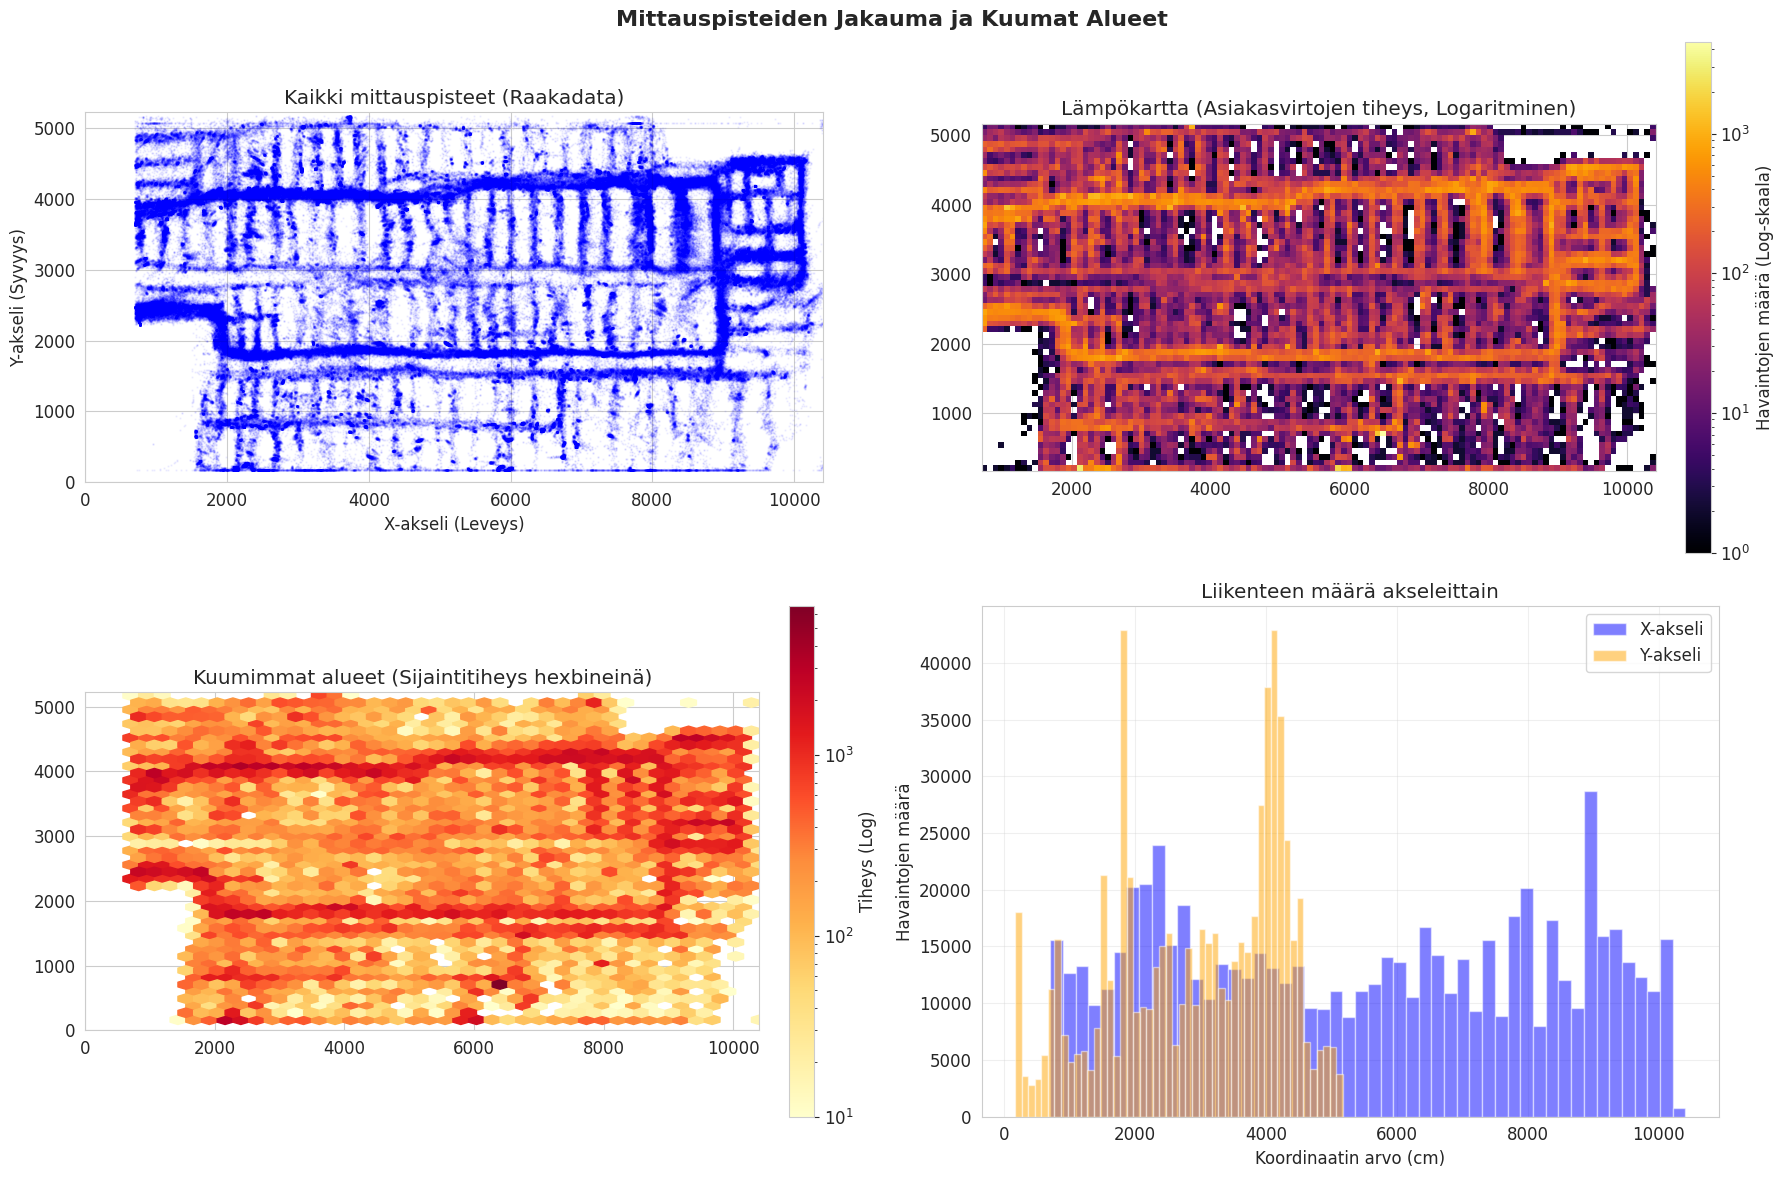

✅ Lämpökartat luotu!


In [119]:
print("\n" + "="*60)
print(" 🗺️ LÄMPÖKARTAT JA KUUMA-ALUEET ")
print("="*60)

df_xy = df_cleaned[['x', 'y']].copy()
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Mittauspisteiden Jakauma ja Kuumat Alueet', fontsize=16, fontweight='bold')

# 1. Perus scatter plot (pieni alpha ja koko, jotta ei mene tukkoon)
axes[0, 0].scatter(df_xy['x'], df_xy['y'], alpha=0.05, s=0.5, c='blue')
axes[0, 0].set_xlabel('X-akseli (Leveys)')
axes[0, 0].set_ylabel('Y-akseli (Syvyys)')
axes[0, 0].set_title('Kaikki mittauspisteet (Raakadata)')
axes[0, 0].set_aspect('equal')
axes[0, 0].set_xlim(0, MAX_X)
axes[0, 0].set_ylim(0, MAX_Y)

# 2. Lämpökartta Logaritmikoolla (Paljastaa kaikki reitit selkeästi)
# LogNorm varmistaa, että yksittäinen tulikuuma paikka ei pimennä muita
h = axes[0, 1].hist2d(df_xy['x'], df_xy['y'], bins=[120, 60], cmap='inferno', norm=LogNorm())
axes[0, 1].set_title('Lämpökartta (Asiakasvirtojen tiheys, Logaritminen)')
axes[0, 1].set_aspect('equal')
plt.colorbar(h[3], ax=axes[0, 1], label='Havaintojen määrä (Log-skaala)', fraction=0.046, pad=0.04)

# 3. Hexbin Kuuma-alueet (Top Locations korvaaja)
# Tämä näyttää kaikkein suosituimmat paikat selkeinä hunajakennoina
hb = axes[1, 0].hexbin(df_xy['x'], df_xy['y'], gridsize=40, cmap='YlOrRd', mincnt=10, bins='log')
axes[1, 0].set_title('Kuumimmat alueet (Sijaintitiheys hexbineinä)')
axes[1, 0].set_aspect('equal')
axes[1, 0].set_xlim(0, MAX_X)
axes[1, 0].set_ylim(0, MAX_Y)
plt.colorbar(hb, ax=axes[1, 0], label='Tiheys (Log)', fraction=0.046, pad=0.04)

# 4. X- ja Y-akselien jakauma
axes[1, 1].hist(df_xy['x'], bins=50, alpha=0.5, label='X-akseli', color='blue')
axes[1, 1].hist(df_xy['y'], bins=50, alpha=0.5, label='Y-akseli', color='orange')
axes[1, 1].set_xlabel('Koordinaatin arvo (cm)')
axes[1, 1].set_ylabel('Havaintojen määrä')
axes[1, 1].set_title('Liikenteen määrä akseleittain')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Lämpökartat luotu!")

## 🛑 Pysähtymispaikat (Dwell Time Analytics)
Vähittäiskaupassa on tärkeää tietää, missä asiakkaat viettävät eniten aikaa (esim. tutkimassa tuotteita). Tämä analyysi eristää ne alueet, joissa asiakkaan nopeus hidastuu alle kävelyvauhdin.


 🛑 PYSÄHTYMISPAIKAT (DWELL TIME) 


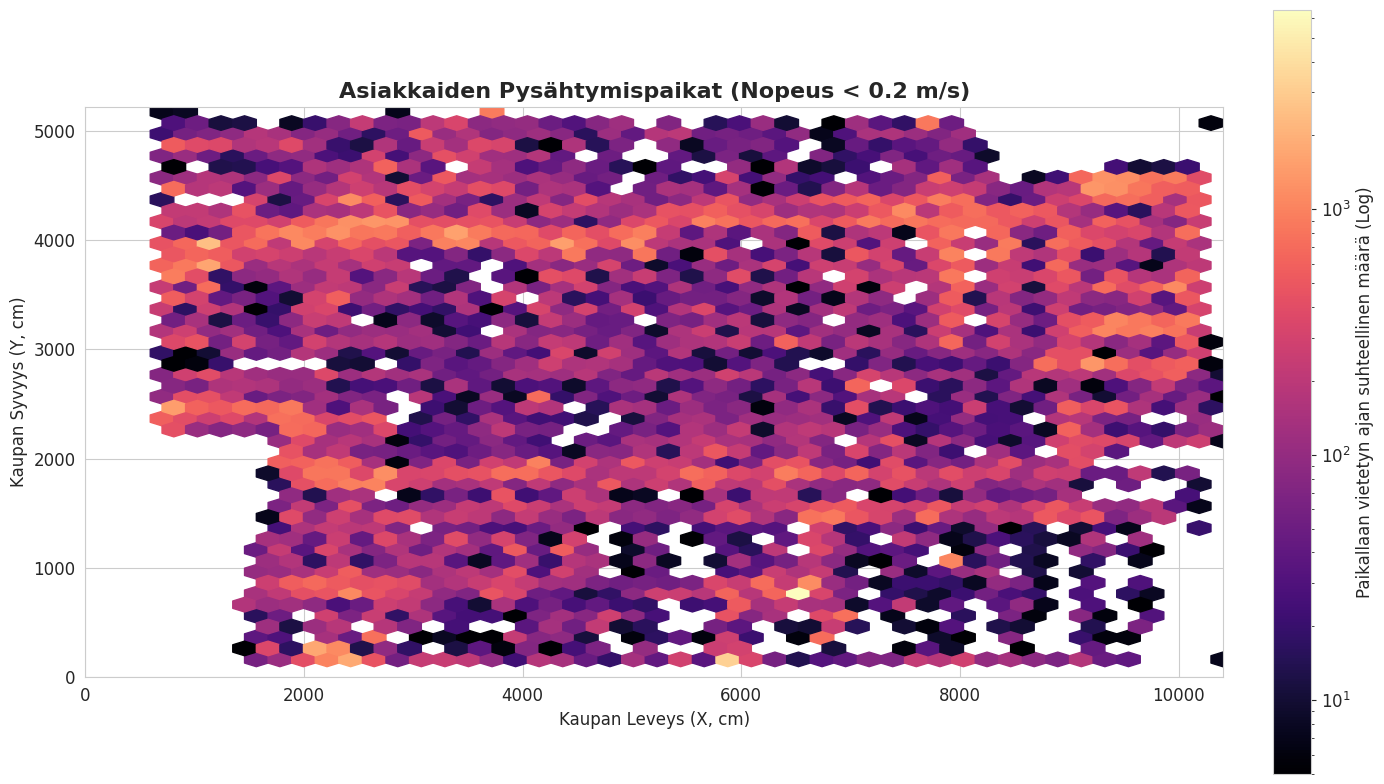

✅ Pysähtymispaikkojen analyysi valmis! Kartta näyttää alueet, joissa asiakkaat viipyvät pisimpään.


In [120]:
print("\n" + "="*60)
print(" 🛑 PYSÄHTYMISPAIKAT (DWELL TIME) ")
print("="*60)

# Määritellään "pysähtyminen" tai hidas liike (alle 0.2 metriä sekunnissa)
DWELL_SPEED_LIMIT = 0.2
df_dwell = df_cleaned[df_cleaned['speed_mps'] < DWELL_SPEED_LIMIT]

fig, ax = plt.subplots(figsize=(14, 8))
hb = ax.hexbin(df_dwell['x'], df_dwell['y'], gridsize=45, cmap='magma', mincnt=5, bins='log')
ax.set_title('Asiakkaiden Pysähtymispaikat (Nopeus < 0.2 m/s)', fontsize=16, fontweight='bold')
ax.set_xlabel('Kaupan Leveys (X, cm)')
ax.set_ylabel('Kaupan Syvyys (Y, cm)')
ax.set_aspect('equal')
ax.set_xlim(0, MAX_X)
ax.set_ylim(0, MAX_Y)

cb = plt.colorbar(hb, ax=ax, label='Paikallaan vietetyn ajan suhteellinen määrä (Log)', fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print(f"✅ Pysähtymispaikkojen analyysi valmis! Kartta näyttää alueet, joissa asiakkaat viipyvät pisimpään.")

## 🌐 3D-Tiheyskartta (Asiakasvirtojen määrä korkeutena)


 🌐 3D TIHEYSKARTTA (SURFACE PLOT) 


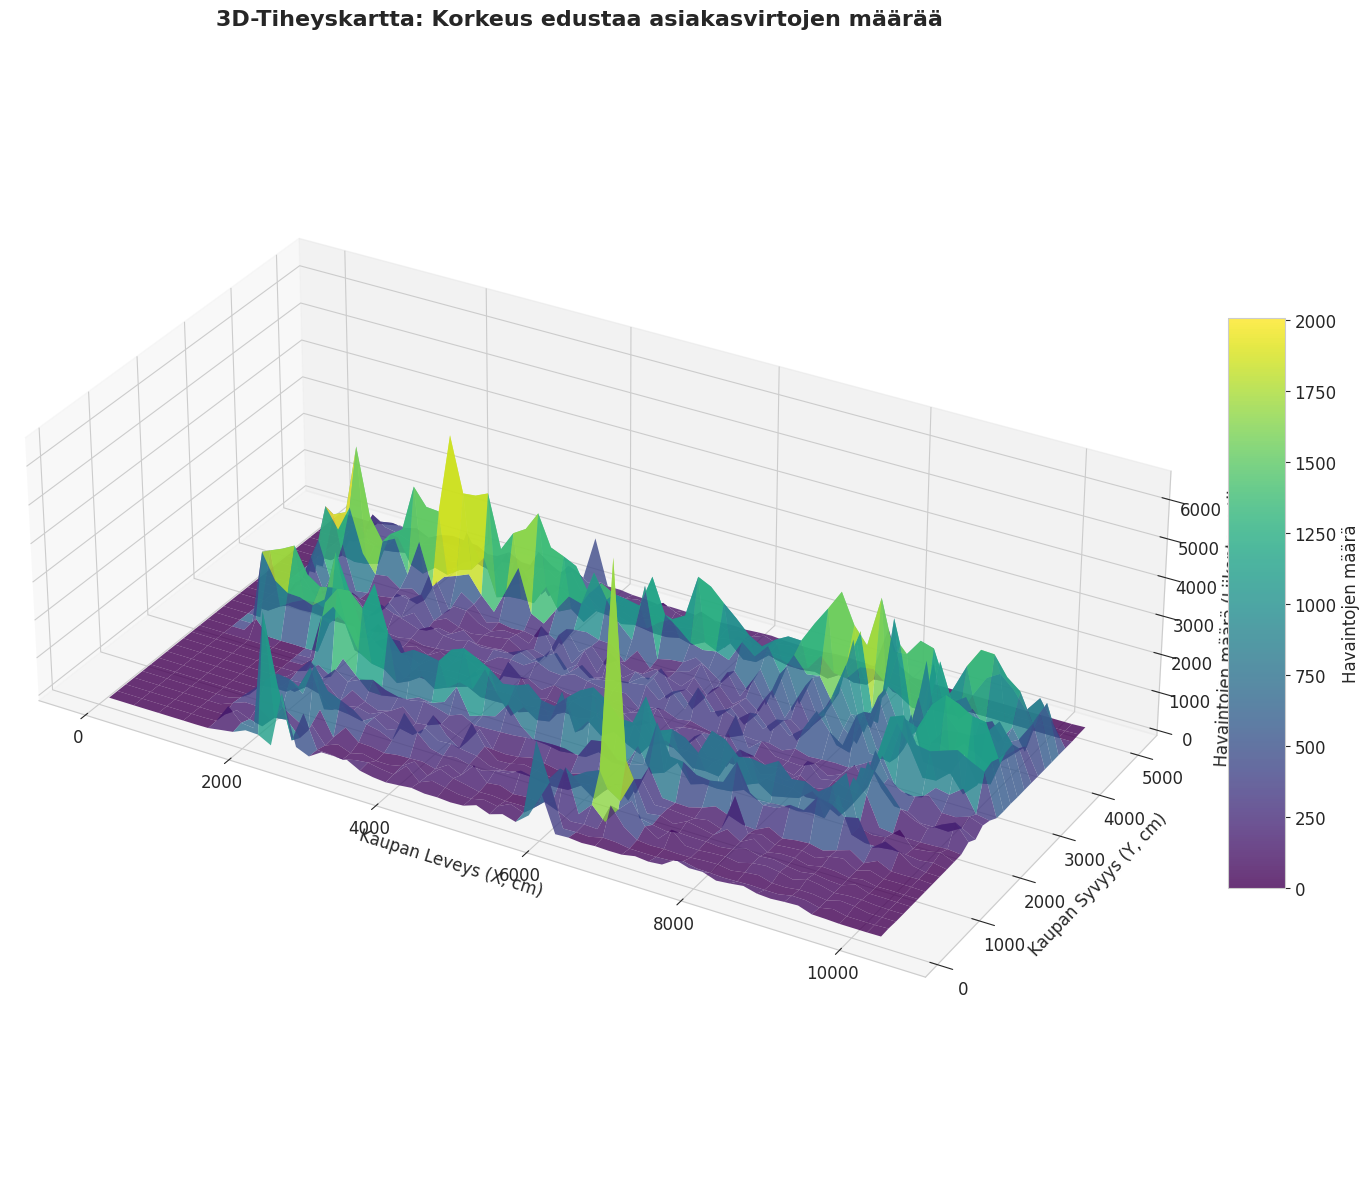

✅ 3D-tiheyskartta luotu! Huippukohdat näyttävät kaupan ruuhkaisimmat pisteet ilman latausasemahäiriöitä.


In [121]:
print("\n" + "="*60)
print(" 🌐 3D TIHEYSKARTTA (SURFACE PLOT) ")
print("="*60)

# Lasketaan kaksiulotteinen histogrammi tiheyden selvittämiseksi
hist, xedges, yedges = np.histogram2d(df_cleaned['x'], df_cleaned['y'], bins=[60, 30], range=[[0, MAX_X], [0, MAX_Y]])

# Luodaan ruudukko 3D-pintaa varten
xpos, ypos = np.meshgrid(xedges[:-1] + (xedges[1]-xedges[0])/2, yedges[:-1] + (yedges[1]-yedges[0])/2, indexing="ij")

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# Piirretään pinta. Z-akseli on nyt asiakkaiden MÄÄRÄ, ei fyysinen korkeus!
surf = ax.plot_surface(xpos, ypos, hist, cmap='viridis', edgecolor='none', alpha=0.8)

ax.set_title('3D-Tiheyskartta: Korkeus edustaa asiakasvirtojen määrää', fontsize=16, fontweight='bold')
ax.set_xlabel('Kaupan Leveys (X, cm)')
ax.set_ylabel('Kaupan Syvyys (Y, cm)')
ax.set_zlabel('Havaintojen määrä (Liikenteen tiheys)')

# Oikeat mittasuhteet (Z-akseli pidetään maltillisena, jotta huiput erottuvat)
ax.set_box_aspect((2, 1, 0.6))

fig.colorbar(surf, shrink=0.5, aspect=10, label='Havaintojen määrä')

plt.tight_layout()
plt.show()

print("✅ 3D-tiheyskartta luotu! Huippukohdat näyttävät kaupan ruuhkaisimmat pisteet ilman latausasemahäiriöitä.")

## 📊 Signaalivahvuuden (Q-arvojen) Jakautuminen


 📊 Q-ARVOJEN (SIGNAALIVAHVUUDEN) JAKAUTUMINEN 


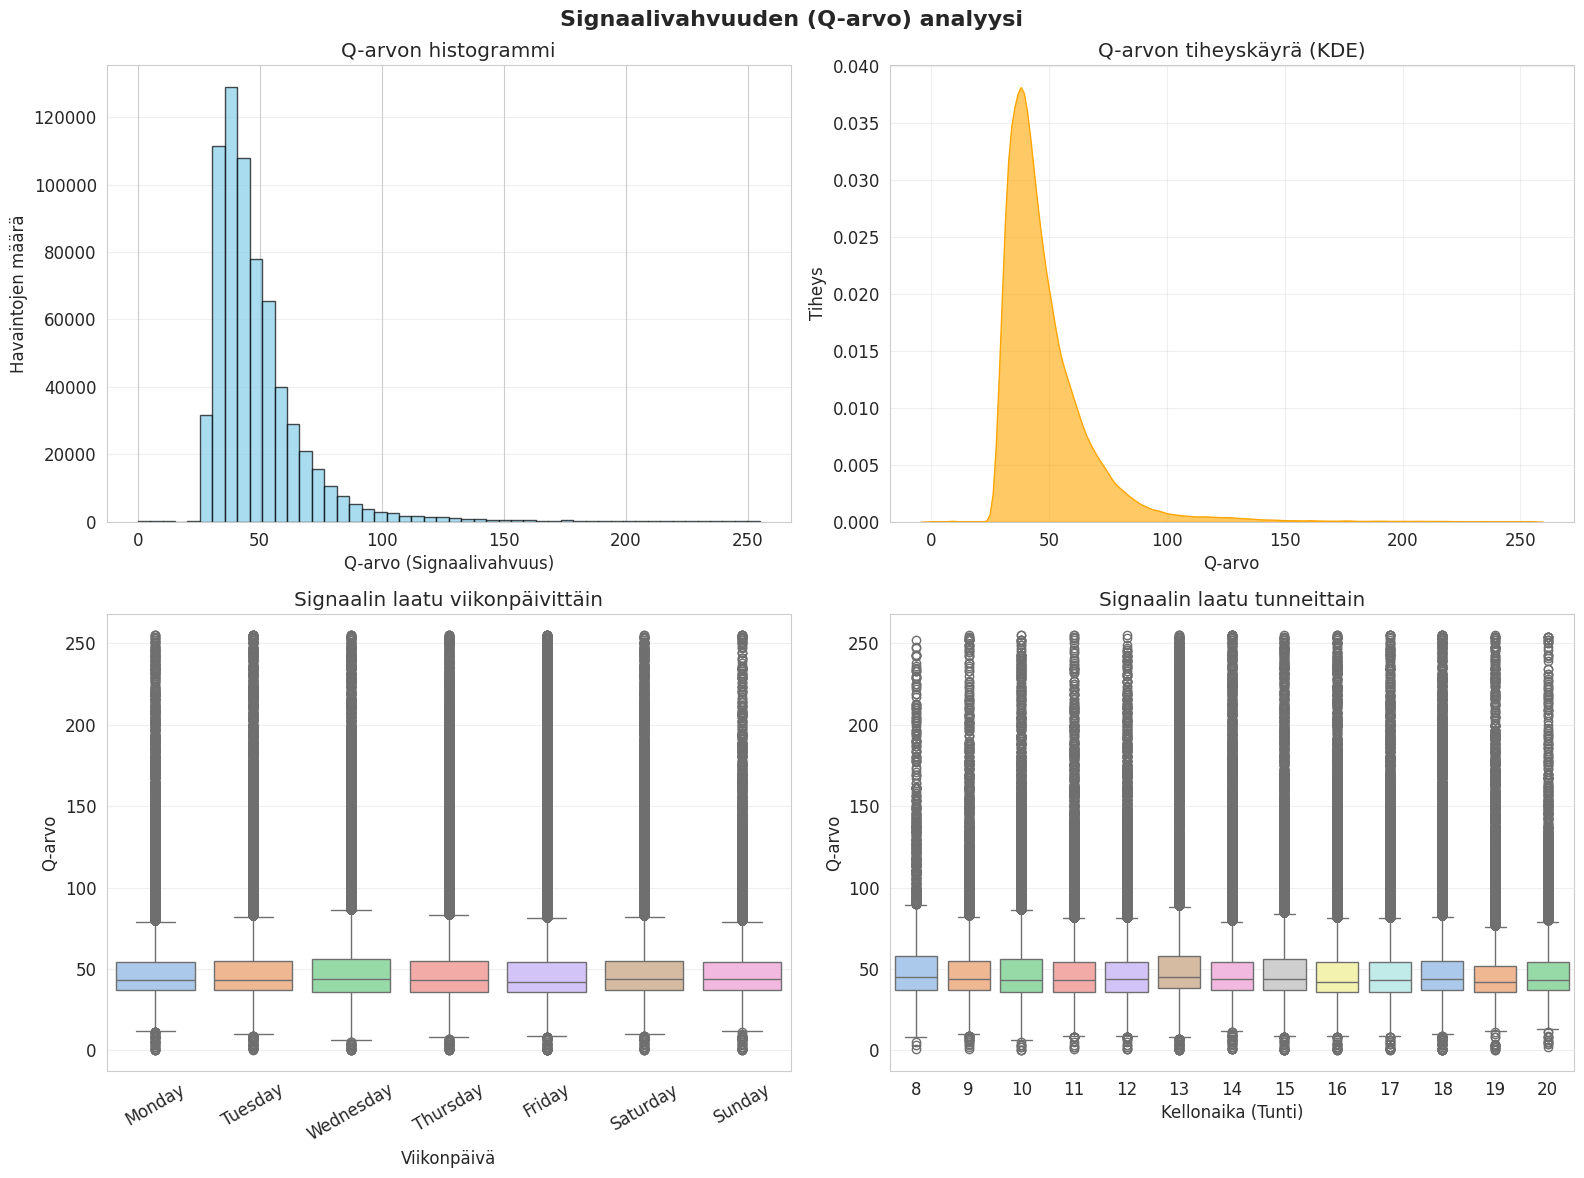

✅ Q-arvojen jakaumat visualisoitu!


In [122]:
if 'q' in df_cleaned.columns:
    print("\n" + "="*60)
    print(" 📊 Q-ARVOJEN (SIGNAALIVAHVUUDEN) JAKAUTUMINEN ")
    print("="*60)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Signaalivahvuuden (Q-arvo) analyysi', fontsize=16, fontweight='bold')

    # 1. Histogrammi (Perusjakauma)
    axes[0, 0].hist(df_cleaned['q'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Q-arvo (Signaalivahvuus)')
    axes[0, 0].set_ylabel('Havaintojen määrä')
    axes[0, 0].set_title('Q-arvon histogrammi')
    axes[0, 0].grid(True, alpha=0.3, axis='y')

    # 2. KDE plot (Tiheyskäyrä)
    sns.kdeplot(data=df_cleaned['q'], ax=axes[0, 1], fill=True, alpha=0.6, color='orange')
    axes[0, 1].set_xlabel('Q-arvo')
    axes[0, 1].set_ylabel('Tiheys')
    axes[0, 1].set_title('Q-arvon tiheyskäyrä (KDE)')
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Q-arvon laatikkovisualisointi (Boxplot) viikonpäivittäin
    # Näyttää, vaihteleeko signaalin laatu eri päivinä
    weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    sns.boxplot(x='weekday', y='q', data=df_cleaned, order=weekday_order, ax=axes[1, 0], palette='pastel')
    axes[1, 0].set_xlabel('Viikonpäivä')
    axes[1, 0].set_ylabel('Q-arvo')
    axes[1, 0].set_title('Signaalin laatu viikonpäivittäin')
    axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=30)
    axes[1, 0].grid(True, alpha=0.3, axis='y')

    # 4. Q-arvon laatikkovisualisointi (Boxplot) tunneittain
    # Valitaan vain tunnit, joilla on dataa
    valid_hours = sorted(df_cleaned['hour'].unique())
    sns.boxplot(x='hour', y='q', data=df_cleaned, ax=axes[1, 1], palette='pastel', order=valid_hours)
    axes[1, 1].set_xlabel('Kellonaika (Tunti)')
    axes[1, 1].set_ylabel('Q-arvo')
    axes[1, 1].set_title('Signaalin laatu tunneittain')
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print("✅ Q-arvojen jakaumat visualisoitu!")
else:
    print("⚠️ Saraketta 'q' ei löydy, ohitetaan signaalivahvuuden analyysi.")

## 🛤️ Yksittäisen Kauppareissun Visualisointi


 🛤️ YKSITTÄISEN OSTOSREITIN SEURANTA 

👤 Näytetään yksittäinen ostoskierros: Sessio 3224_238
   - Aikaleima alussa: 2019-09-21 08:50:20.554767+03:00
   - Datapisteitä: 278
   - Aikaa kului: 4.3 minuuttia
   - Kuljettu matka: 123.87 metriä


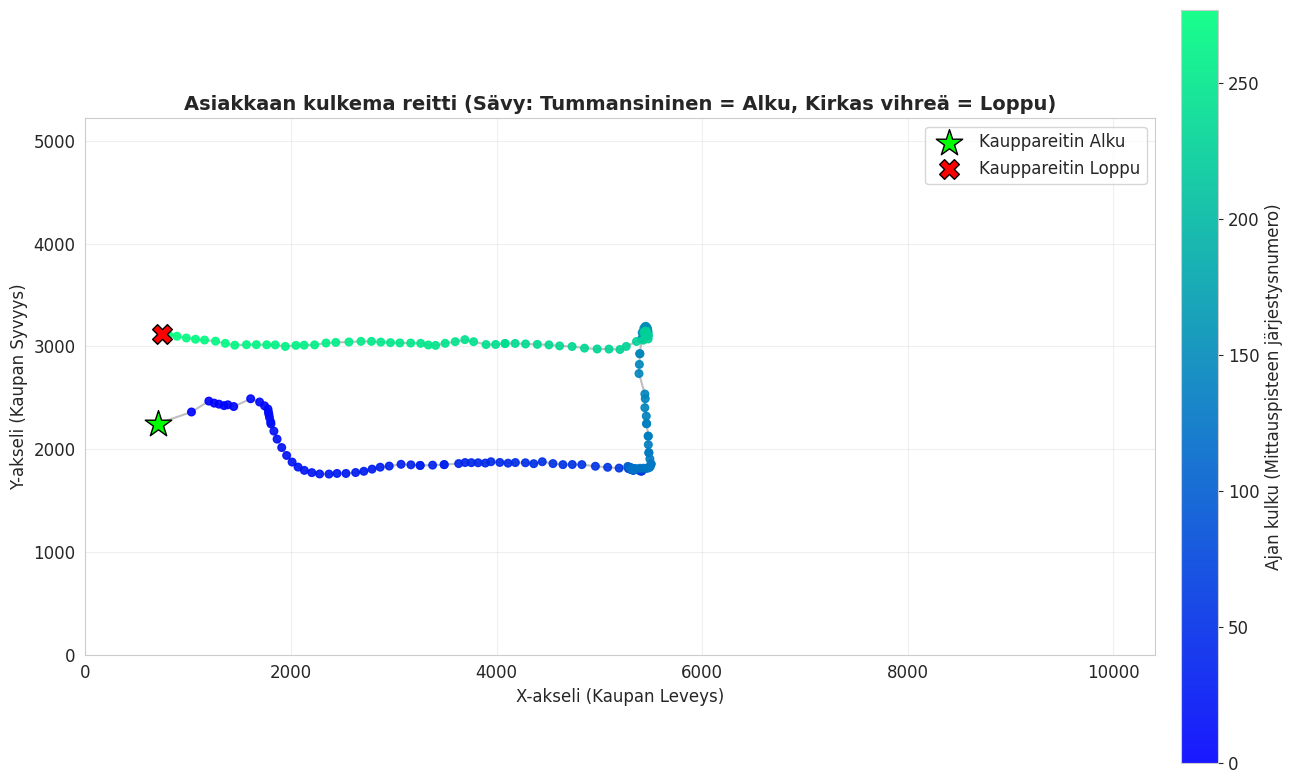

✅ Reitin visualisointi valmis! Voit ajaa tämän solun uudestaan nähdäksesi eri asiakkaan reitin.


In [142]:
print("\n" + "="*60)
print(" 🛤️ YKSITTÄISEN OSTOSREITIN SEURANTA ")
print("="*60)

valid_sessions = df_cleaned['full_session_id'].unique()

if len(valid_sessions) > 0:
    # Valitaan satunnainen yksittäinen reissu
    random_session_id = np.random.choice(valid_sessions)
    user_data = df_cleaned[df_cleaned['full_session_id'] == random_session_id].sort_values('timestamp')
    
    print(f"\n👤 Näytetään yksittäinen ostoskierros: Sessio {random_session_id}")
    print(f"   - Aikaleima alussa: {user_data['timestamp'].iloc[0]}")
    print(f"   - Datapisteitä: {len(user_data)}")
    print(f"   - Aikaa kului: {(user_data['timestamp'].max() - user_data['timestamp'].min()).total_seconds() / 60:.1f} minuuttia")
    print(f"   - Kuljettu matka: {user_data['dist_m'].sum():.2f} metriä")
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Piirretään reittiviiva alle harmaalla
    ax.plot(user_data['x'], user_data['y'], linewidth=1.5, color='gray', alpha=0.5)
    
    # Piirretään pisteet päälle, väri muuttuu ajan kuluessa (järjestysnumero)
    sc = ax.scatter(user_data['x'], user_data['y'], c=range(len(user_data)), cmap='winter', s=30, alpha=0.9, zorder=5)
    
    # Merkitään ALKU (Vihreä tähti) ja LOPPU (Punainen risti)
    ax.scatter(user_data['x'].iloc[0], user_data['y'].iloc[0], color='lime', marker='*', s=400, edgecolor='black', zorder=10, label='Kauppareitin Alku')
    ax.scatter(user_data['x'].iloc[-1], user_data['y'].iloc[-1], color='red', marker='X', s=200, edgecolor='black', zorder=10, label='Kauppareitin Loppu')
    
    ax.set_xlabel('X-akseli (Kaupan Leveys)')
    ax.set_ylabel('Y-akseli (Kaupan Syvyys)')
    ax.set_title(f'Asiakkaan kulkema reitti (Sävy: Tummansininen = Alku, Kirkas vihreä = Loppu)', fontsize=14, fontweight='bold')
    ax.set_aspect('equal') # Oikeat kaupan mittasuhteet
    ax.set_xlim(0, MAX_X)
    ax.set_ylim(0, MAX_Y)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.colorbar(sc, ax=ax, label='Ajan kulku (Mittauspisteen järjestysnumero)', pad=0.02)
    plt.tight_layout()
    plt.show()
    print("✅ Reitin visualisointi valmis! Voit ajaa tämän solun uudestaan nähdäksesi eri asiakkaan reitin.")
else:
    print("Ei tarpeeksi selkeitä yksittäisiä reittejä visualisoitavaksi.")

## 📈 Aikasarja-analyysi


 📈 AIKASARJA-ANALYYSI 


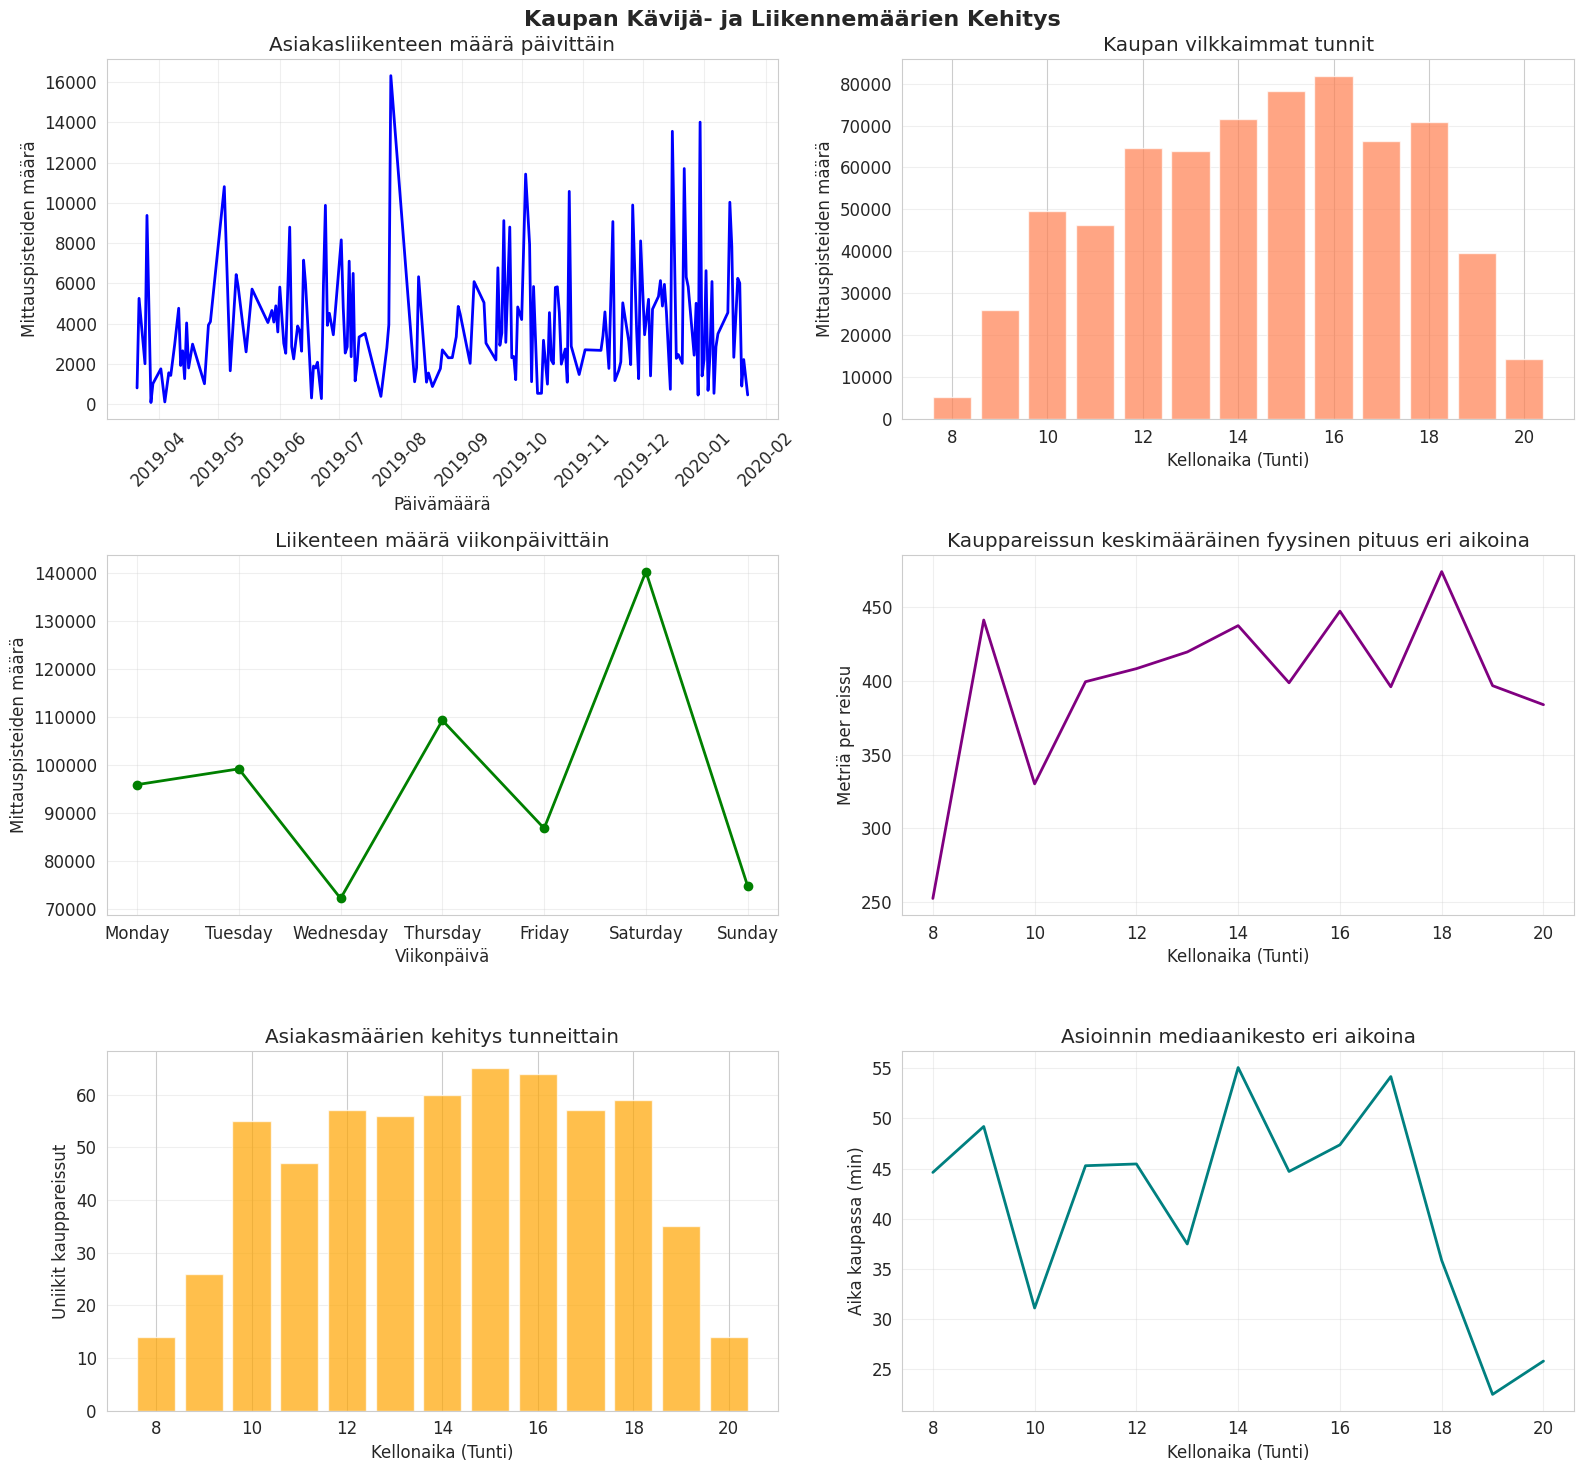

✅ Aikasarja-analyysi valmis!


In [124]:
print("\n" + "="*60)
print(" 📈 AIKASARJA-ANALYYSI ")
print("="*60)

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
fig.suptitle('Kaupan Kävijä- ja Liikennemäärien Kehitys', fontsize=16, fontweight='bold')

# 1. Havaintojen määrä päivittäin
daily_counts = df_cleaned.groupby('date').size()
axes[0, 0].plot(daily_counts.index, daily_counts.values, linewidth=2, color='blue')
axes[0, 0].set_xlabel('Päivämäärä')
axes[0, 0].set_ylabel('Mittauspisteiden määrä')
axes[0, 0].set_title('Asiakasliikenteen määrä päivittäin')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Havaintojen määrä tunnissa
hourly_counts = df_cleaned.groupby('hour').size()
axes[0, 1].bar(hourly_counts.index, hourly_counts.values, color='coral', alpha=0.7)
axes[0, 1].set_xlabel('Kellonaika (Tunti)')
axes[0, 1].set_ylabel('Mittauspisteiden määrä')
axes[0, 1].set_title('Kaupan vilkkaimmat tunnit')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Havaintojen määrä viikonpäivittäin
weekday_counts = df_cleaned.groupby('weekday').size()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = weekday_counts.reindex(weekday_order)
axes[1, 0].plot(weekday_counts.index, weekday_counts.values, marker='o', linewidth=2, color='green')
axes[1, 0].set_xlabel('Viikonpäivä')
axes[1, 0].set_ylabel('Mittauspisteiden määrä')
axes[1, 0].set_title('Liikenteen määrä viikonpäivittäin')
axes[1, 0].grid(True, alpha=0.3)

# 4. Sessioiden keskimääräinen pituus tunnissa
avg_dist_hour = df_cleaned.groupby(['hour', 'full_session_id'])['dist_m'].sum().groupby('hour').mean()
axes[1, 1].plot(avg_dist_hour.index, avg_dist_hour.values, linewidth=2, color='purple')
axes[1, 1].set_xlabel('Kellonaika (Tunti)')
axes[1, 1].set_ylabel('Metriä per reissu')
axes[1, 1].set_title('Kauppareissun keskimääräinen fyysinen pituus eri aikoina')
axes[1, 1].grid(True, alpha=0.3)

# 5. Uniikkien kauppareissujen (Sessioiden) määrä tunnissa
sessions_per_hour = df_cleaned.groupby('hour')['full_session_id'].nunique()
axes[2, 0].bar(sessions_per_hour.index, sessions_per_hour.values, color='orange', alpha=0.7)
axes[2, 0].set_xlabel('Kellonaika (Tunti)')
axes[2, 0].set_ylabel('Uniikit kauppareissut')
axes[2, 0].set_title('Asiakasmäärien kehitys tunneittain')
axes[2, 0].grid(True, alpha=0.3, axis='y')

# 6. Kauppamatkojen mediaanikesto tunnissa
avg_duration_hour = pd.Series(session_durations).groupby(df_cleaned.groupby('full_session_id')['hour'].first()).median()
axes[2, 1].plot(avg_duration_hour.index, avg_duration_hour.values, linewidth=2, color='teal')
axes[2, 1].set_xlabel('Kellonaika (Tunti)')
axes[2, 1].set_ylabel('Aika kaupassa (min)')
axes[2, 1].set_title('Asioinnin mediaanikesto eri aikoina')
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Aikasarja-analyysi valmis!")

## 📝 Datan Yhteenveto, Tallennus ja Verifiointi

In [125]:
print("\n" + "="*60)
print(" 📝 DATAN LOPULLINEN YHTEENVETO JA TALLENNUS ")
print("="*60)

# 1. Luodaan kattava yhteenveto tekstimuodossa
summary = f"""
DATAN YHTEENVETO SIIVOUKSEN JÄLKEEN:
-----------------------------------
- Alkuperäisiä rivejä (raakadata): {cleaning_stats['original_rows']:,}
- Lopullisia rivejä (siivottu data): {len(df_cleaned):,}
- Poistettu yhteensä: {cleaning_stats['original_rows'] - len(df_cleaned):,}

- Uniikkeja ostoskärryjä (Nodeja): {df_cleaned['node_id'].nunique()}
- Tunnistettuja kauppareissuja (Sessioita): {df_cleaned['full_session_id'].nunique():,}

- Kattava aikaväli: {df_cleaned['timestamp'].min()} - {df_cleaned['timestamp'].max()}
- Oikeat koordinaattirajat (cm): X: 0 - {MAX_X}, Y: 0 - {MAX_Y}

- Kauppareissun mediaanikesto: {session_durations.median():.1f} minuuttia
- Kauppareissun mediaanipituus: {session_distances.median():.2f} metriä
- Signaalivahvuuden (Q) mediaani: {df_cleaned['q'].median():.2f}
"""
print(summary)

# 2. Tallenna siivottu data dynaamisella nimellä
raw_path = Path(raw_file)
output_filename = f"processed_{raw_path.name}"
output_path = processed_data_path / output_filename

# Varmistetaan, että hakemisto on olemassa
output_path.parent.mkdir(parents=True, exist_ok=True)

# Poistetaan turhat aputaulut ennen tallennusta
cols_to_drop = ['dt', 'dist_m', 'speed_mps']
df_final = df_cleaned.drop(columns=[c for c in cols_to_drop if c in df_cleaned.columns])

# Tallennetaan data
df_final.to_csv(output_path, index=False)
print(f"💾 Data tallennettu onnistuneesti: {output_path}")
print(f"   - Tiedostokoko: {output_path.stat().st_size / 1024 / 1024:.2f} MB")

# 3. Verifiointi: Luetaan data takaisin ja tarkistetaan, että kaikki on kunnossa
if output_path.exists():
    df_verify = pd.read_csv(output_path)
    print(f"\n✓ Verifiointi onnistui: Data luettavissa takaisin.")
    print(f"  - Rivejä: {len(df_verify):,}, Sarakkeita: {len(df_verify.columns)}")
    print(f"  - Muistinkäyttö: {df_verify.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")
else:
    print("\n✗ Virhe tallennuksessa: Tiedostoa ei löydy.")

print("\n✅ Laajennettu analyysi ja datan siivousprosessi on valmis!")


 📝 DATAN LOPULLINEN YHTEENVETO JA TALLENNUS 

DATAN YHTEENVETO SIIVOUKSEN JÄLKEEN:
-----------------------------------
- Alkuperäisiä rivejä (raakadata): 6,136,400
- Lopullisia rivejä (siivottu data): 678,234
- Poistettu yhteensä: 5,458,166

- Uniikkeja ostoskärryjä (Nodeja): 1
- Tunnistettuja kauppareissuja (Sessioita): 321

- Kattava aikaväli: 2019-03-21 18:14:07.694369+02:00 - 2020-01-23 13:20:10.471317+02:00
- Oikeat koordinaattirajat (cm): X: 0 - 10406, Y: 0 - 5220

- Kauppareissun mediaanikesto: 42.5 minuuttia
- Kauppareissun mediaanipituus: 648.61 metriä
- Signaalivahvuuden (Q) mediaani: 43.00

💾 Data tallennettu onnistuneesti: data/processed/processed_node_3224.csv
   - Tiedostokoko: 55.79 MB

✓ Verifiointi onnistui: Data luettavissa takaisin.
  - Rivejä: 678,234, Sarakkeita: 11
  - Muistinkäyttö: 199.86 MB

✅ Laajennettu analyysi ja datan siivousprosessi on valmis!
